In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/indianDataset/indiandataset.zip"
extract_path = "/content/indiandatset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
import os

print(os.listdir(extract_path))

['Indian-Traffic Sign-Dataset']


In [ ]:
import pandas as pd
import os
# Load CSV
df = pd.read_csv( os.path.join(extract_path,'Indian-Traffic Sign-Dataset','traffic_sign.csv'))
# Show first rows
df.head()

,ClassId,Name
0,0,Give way
1,1,No entry
2,2,One-way traffic
3,3,One-way traffic
4,4,No vehicles in both directions


In [ ]:
print(df.columns)
print("Total Classes:", len(df))

Index(['ClassId', 'Name'], dtype='object')
Total Classes: 59


In [ ]:
import numpy as np
import cv2
import os

# Empty lists
X = []
y = []

IMG_SIZE = 64   # IMPORTANT for ResNet50

images_base_dir = os.path.join(
    extract_path,
    'Indian-Traffic Sign-Dataset',
    'Images'
)

for class_folder in os.listdir(images_base_dir):

    class_path = os.path.join(images_base_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_file in os.listdir(class_path):

        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize for ResNet50
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        y.append(int(class_folder))


# Convert to arrays
X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (13971, 64, 64, 3)
Labels: (13971,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.30,random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(y_train,y_temp,test_size=0.50,random_state=42,stratify=y_temp)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (9779, 64, 64, 3)
X_val: (2096, 64, 64, 3)
X_test: (2096, 64, 64, 3)
y_train: (9779,)
y_val: (2096,)
y_test: (2096,)


In [ ]:
#Preprocess images
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
# Preprocess images for ResNet50
X_train = preprocess_input(X_train.astype('float32'))
X_val = preprocess_input(X_val.astype('float32'))
X_test = preprocess_input(X_test.astype('float32'))
# One-hot encode labels
y_train = to_categorical(y_train, 59)
y_val = to_categorical(y_val, 59)
y_test = to_categorical(y_test, 59)
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(9779, 64, 64, 3)
(9779, 59)
(2096, 64, 64, 3)
(2096, 59)
(2096, 64, 64, 3)
(2096, 59)


In [ ]:
#build the ResNet50 transfer learning model.
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load pretrained ResNet50
base_model = ResNet50( weights='imagenet', include_top=False, input_shape=(64,64,3))
# Freeze pretrained layers
base_model.trainable = False
# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(59, activation='softmax')(x)

model = Model(inputs=base_model.input,
              outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,667,067 (94.10 MB)

 Trainable params: 1,079,355 (4.12 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#EarlyStopping + ReduceLR + ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
early_stop = EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3, min_lr=1e-6)
checkpoint = ModelCheckpoint(
    "best_resnet50_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.3662 - loss: 3.0277

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 542ms/step - accuracy: 0.4737 - loss: 2.0631 - val_accuracy: 0.6794 - val_loss: 0.9738 - learning_rate: 0.0010
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6326 - loss: 1.1508

306/306 ━━━━━━━━━━━━━━━━━━━━ 200s 536ms/step - accuracy: 0.6450 - loss: 1.1011 - val_accuracy: 0.7462 - val_loss: 0.8017 - learning_rate: 0.0010
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6877 - loss: 0.9288

306/306 ━━━━━━━━━━━━━━━━━━━━ 175s 572ms/step - accuracy: 0.6982 - loss: 0.8940 - val_accuracy: 0.7643 - val_loss: 0.7020 - learning_rate: 0.0010
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7353 - loss: 0.7687

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 571ms/step - accuracy: 0.7381 - loss: 0.7681 - val_accuracy: 0.7677 - val_loss: 0.6786 - learning_rate: 0.0010
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7643 - loss: 0.6817

...

306/306 ━━━━━━━━━━━━━━━━━━━━ 202s 524ms/step - accuracy: 0.8055 - loss: 0.5420 - val_accuracy: 0.8049 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 13/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 215s 565ms/step - accuracy: 0.8237 - loss: 0.4953 - val_accuracy: 0.7929 - val_loss: 0.6217 - learning_rate: 0.0010
Epoch 14/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8539 - loss: 0.4263

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 568ms/step - accuracy: 0.8611 - loss: 0.3907 - val_accuracy: 0.8173 - val_loss: 0.5559 - learning_rate: 5.0000e-04
Epoch 15/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 189s 523ms/step - accuracy: 0.8737 - loss: 0.3487 - val_accuracy: 0.8168 - val_loss: 0.5316 - learning_rate: 5.0000e-04
Epoch 16/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 201s 522ms/step - accuracy: 0.8768 - loss: 0.3328 - val_accuracy: 0.8173 - val_loss: 0.5372 - learning_rate: 5.0000e-04
Epoch 17/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.8859 - loss: 0.3157

306/306 ━━━━━━━━━━━━━━━━━━━━ 174s 571ms/step - accuracy: 0.8795 - loss: 0.3254 - val_accuracy: 0.8197 - val_loss: 0.5627 - learning_rate: 5.0000e-04
Epoch 18/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 173s 567ms/step - accuracy: 0.8831 - loss: 0.3158 - val_accuracy: 0.8144 - val_loss: 0.5741 - learning_rate: 5.0000e-04
Epoch 19/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9028 - loss: 0.2816

306/306 ━━━━━━━━━━━━━━━━━━━━ 204s 571ms/step - accuracy: 0.9014 - loss: 0.2818 - val_accuracy: 0.8235 - val_loss: 0.5378 - learning_rate: 2.5000e-04
Epoch 20/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9059 - loss: 0.2563

306/306 ━━━━━━━━━━━━━━━━━━━━ 161s 527ms/step - accuracy: 0.9057 - loss: 0.2660 - val_accuracy: 0.8273 - val_loss: 0.5491 - learning_rate: 2.5000e-04


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.8220 - loss: 0.5225
Test Accuracy: 0.8220419883728027
Test Loss: 0.5224942564964294


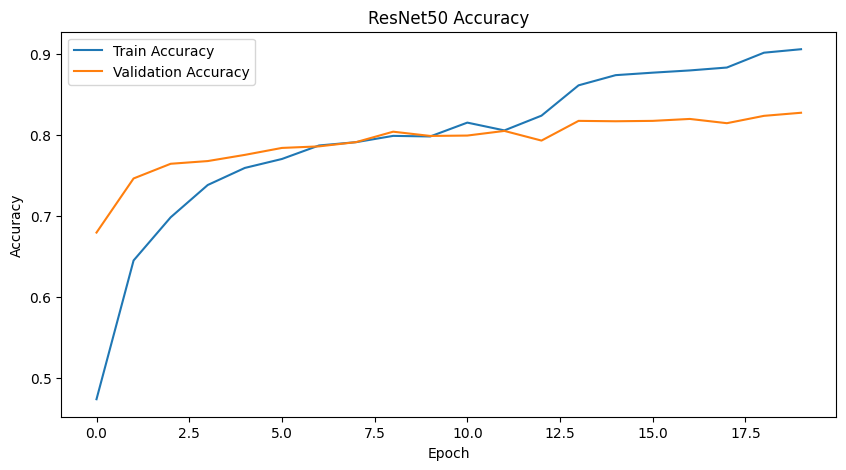

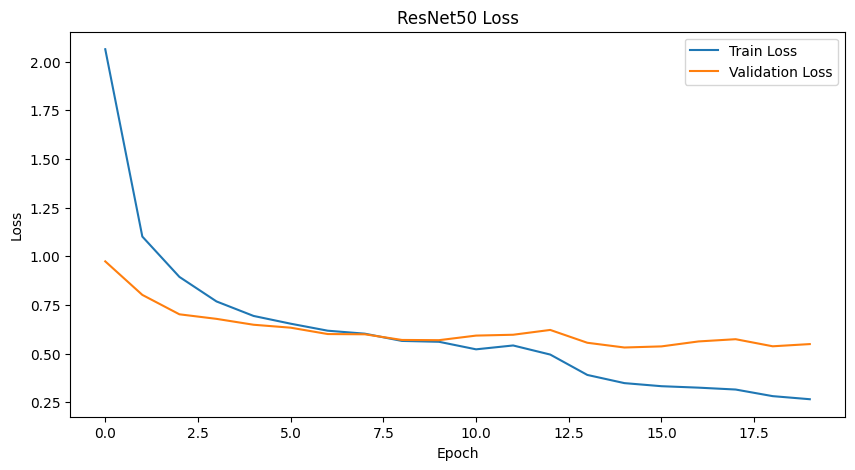

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.show()

66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 662ms/step


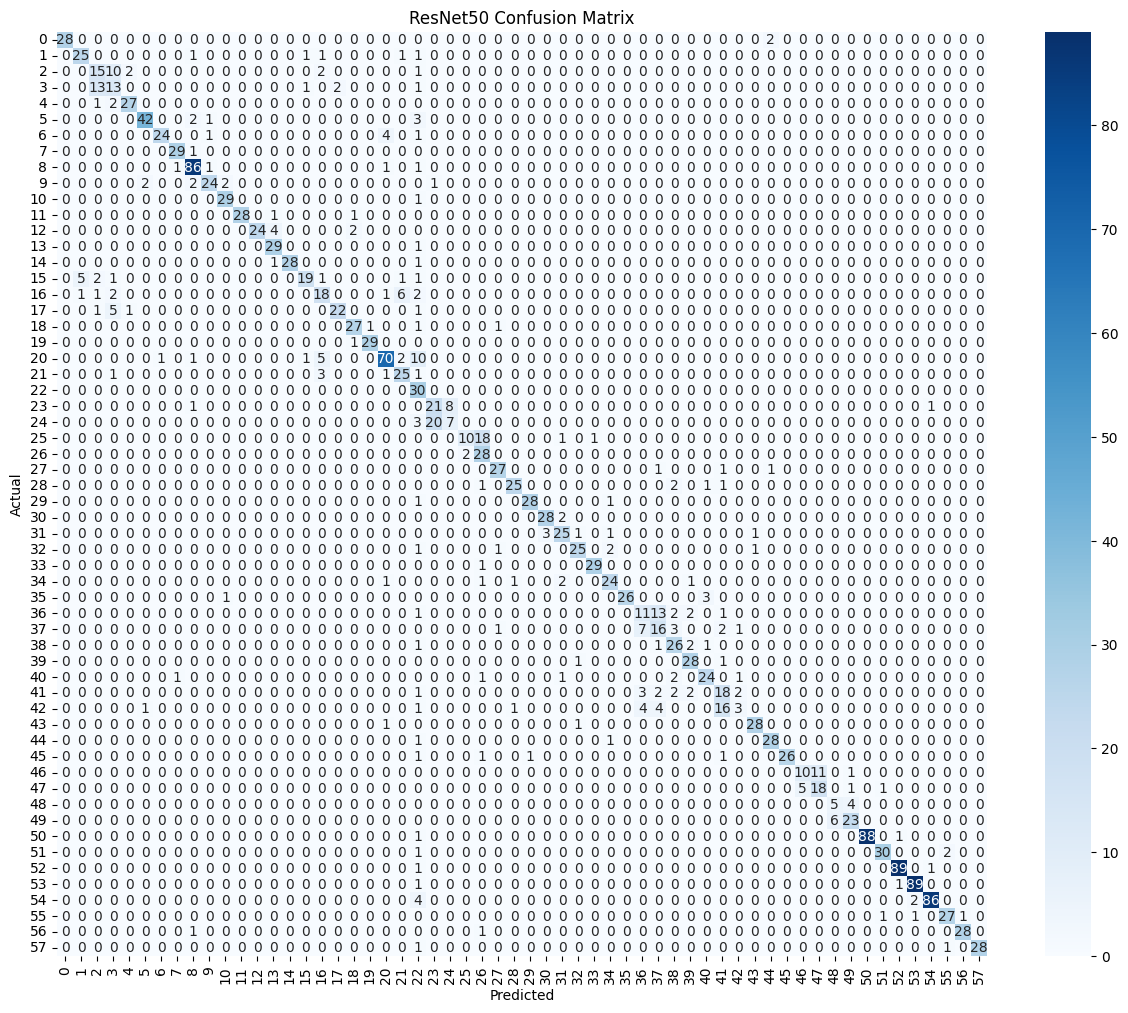

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.81      0.83      0.82        30
           2       0.45      0.50      0.48        30
           3       0.38      0.43      0.41        30
           4       0.90      0.90      0.90        30
           5       0.93      0.88      0.90        48
           6       0.96      0.80      0.87        30
           7       0.94      0.97      0.95        30
           8       0.91      0.96      0.93        90
           9       0.89      0.77      0.83        31
          10       0.91      0.97      0.94        30
          11       1.00      0.93      0.97        30
          12       1.00      0.80      0.89        30
          13       0.83      0.97      0.89        30
          14       1.00      0.93      0.97        30
          15       0.86      0.63      0.73        30
          16       0.60      0.58      0.59        31
          17       0.92    

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Convert one-hot → labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(15,12))
sns.heatmap(cm,
            cmap='Blues',
            annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes))